# Equivalence analysis (TOST) for the setup and finger null effects

**Standalone.** Reads the per-participant PSE/JND fits written by the psychophysics pipeline and
does not import `anova_statistics`. Run with the system Python (pandas, scipy, pingouin, matplotlib).
Re-running this notebook on new data regenerates every number, table and figure that the paper's
equivalence paragraph, companion ANOVA sentence and equivalence figure use.

**Goal.** Replace "*p* > .05, therefore flexible finger selection" with "the difference, if any, is
smaller than a perceptually meaningful amount" (Lakens, 2017).

| Section | What | Outputs (`results/<cohort>/`) |
|---|---|---|
| 0 | Setup and configuration | -- |
| 1 | Load, validate, cohort, exclusion-rule check | -- |
| 2 | Step 0: per-participant fits vs pooled fits | `csv/step0.csv` |
| 3 | Step 1: pre-specified bounds | -- |
| 4 | Step 2: feasibility | `csv/step2.csv` |
| 5 | Step 3: TOST (setup, finger pairs, bias vs 0) | `csv/setup.csv`, `pairs.csv`, `zero.csv`, `verdict.csv` |
| 6 | Companion ANOVA, Holm post hoc, robustness | `csv/anova.csv`, `posthoc.csv`, `robust.csv` |
| 7 | Step 4: Bayes factors, JASP export | `csv/bf_ttest.csv`, `bf_pairs.csv`, `for_jasp_wide.csv` |
| 8 | Step 5: minimal detectable effect | `csv/mde.csv` |
| 9 | Step 6: sensitivity to extra exclusions | `csv/sensitivity.csv` |
| 10 | Figures | `figures/equivalence_paper*.{png,pdf}` |
| 11 | Report sentences | `report_sentences.md` |


## 0. Setup and configuration

`DATA_SELECTION` names the psychophysics results folder (as in the ANOVA notebook). Participants whose
raw-data folder is tagged `(filter)` are excluded automatically; `EXTRA_SENSITIVITY_EXCLUSIONS` are
removed only in section 9 to show the conclusions do not hinge on them. Bounds are constants in the
module and were fixed before any TOST outcome was read.

In [1]:
import os, warnings, importlib
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
from IPython.display import display, Image, Markdown
import tost_equivalence as T
T = importlib.reload(T)

DATA_SELECTION = "L_N_E"                      # psychophysics results folder
EXCLUDED = T.excluded_subjects()              # from "(filter)" raw folders
EXTRA_SENSITIVITY_EXCLUSIONS = ("L_E_6", "L_E_18")   # section 9 only
PAPER_PANELS = ("bias", "jnd")                # or ("bias",) for the compact figure

DATA_PATH = T.data_path(DATA_SELECTION)
print("data:", DATA_PATH)
print("excluded from every analysis:", EXCLUDED)
print("bounds: bias", T.SESOI_BIAS, "| JND abs +/-", T.SESOI_JND_ABS, "| JND ratio x", T.SESOI_JND_RATIO)
print("success rule used in the paper:", T.SUCCESS_RULE)


data: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\analysis\psychophysics\results\L_N_E\csv\all\shared\pse_jnd_by_subject_finger.csv
excluded from every analysis: ('L_E_19', 'N_E_17')
bounds: bias {'1 JND': 1.6, '0.5 JND': 0.8} | JND abs +/- 0.5 | JND ratio x 1.3
success rule used in the paper: {'threshold': 0.6, 'min_fingers': 2}


## 1. Load and validate

Units are checked (PSE median must be near 8.5 mm/m). The exclusion rule stated in the paper is checked
against the per-finger success rates of every participant who finished, including the filtered ones,
which are scored with the pipeline's own loader.

In [2]:
df = T.load_fits(DATA_PATH, EXCLUDED)
C = T.cohort_summary(df)
COHORT = f"{DATA_SELECTION}_N{C['N']}"
P = T.output_dirs(T.OUT_ROOT, COHORT)
print(f"cohort {COHORT}: N = {C['N']} ({C['n_L']} air-slide, {C['n_N']} natural), {C['fits']} fits")
print("outputs ->", P["root"])
display(df.head())

sr = T.success_by_finger(DATA_SELECTION, include_filtered=True)
rules = T.exclusion_rule_table(sr)
display(rules)
paper_rule = T.apply_success_rule(sr, T.SUCCESS_RULE["threshold"], T.SUCCESS_RULE["min_fingers"])
print("paper rule excludes:", paper_rule, "| matches the filtered set:", sorted(paper_rule) == sorted(EXCLUDED))


cohort L_N_E_N39: N = 39 (20 air-slide, 19 natural), 156 fits
outputs -> C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\analysis\tost_equivalence\results\L_N_E_N39


,Subject,System,Finger,PSE,JND,fit_quality,fit_warning,n_trials,Bias,logJND
0,L_E_1,L,I,9.110860,1.453587,ok,NaN,64,0.610860,0.374034
1,L_E_1,L,M,8.243803,1.675686,ok,NaN,64,-0.256197,0.516222
2,L_E_1,L,P,6.936302,0.147895,warning,high_lapse_estimate,64,-1.563698,-1.911251
3,L_E_1,L,R,6.876752,1.909695,warning,high_lapse_estimate,64,-1.623248,0.646944
4,L_E_10,L,I,9.049993,3.080801,warning,high_lapse_estimate,64,0.549993,1.125190


,rule,n_excluded,excluded
0,>=60% on >=2 fingers (paper),2,"L_E_19, N_E_17"
1,>=60% on >=3 fingers,2,"L_E_19, N_E_17"
2,>=60% on all fingers,4,"L_E_18, L_E_19, L_E_6, N_E_17"
3,>=55% on all fingers,2,"L_E_19, N_E_17"
4,>50% on all fingers,2,"L_E_19, N_E_17"


paper rule excludes: ['L_E_19', 'N_E_17'] | matches the filtered set: True


## 2. Step 0: per-participant fits and the pooled fits

One 4-parameter logistic fit per participant x finger (64 trials each). Per-participant summaries are
shown next to the pooled group fit for the same finger; they need not coincide but should tell the
same story.

In [3]:
step0 = T.step0_consistency(df, T.pooled_path(DATA_SELECTION)); step0.to_csv(os.path.join(P["csv"], "step0.csv"), index=False)
display(step0.round(2))
JND_REF = T.jnd_reference(df)
print(f"Median per-participant JND (anchor for the bias bound): {JND_REF:.2f} mm/m")


,Finger,n fits,trials/fit,Bias mean,Bias SD,Bias median,Bias IQR,JND mean,JND SD,JND median,JND IQR,pooled bias,pooled JND,pooled trials
0,Index,39,64,0.17,1.22,0.33,"[-0.83, 1.10]",2.27,1.96,1.59,"[1.01, 2.74]",0.02,2.50,2496
1,Middle,39,64,0.33,1.26,0.27,"[-0.43, 1.15]",2.93,2.64,2.33,"[1.19, 4.45]",-0.07,2.71,2496
2,Ring,39,64,-0.11,1.33,0.10,"[-1.42, 0.88]",1.74,1.56,1.53,"[0.28, 2.17]",-0.04,2.40,2496
3,Little,39,64,0.01,1.48,0.25,"[-1.26, 1.03]",2.19,2.48,1.36,"[0.87, 2.85]",-0.28,2.28,2496


Median per-participant JND (anchor for the bias bound): 1.61 mm/m


## 3. Step 1: pre-specified bounds

* **PSE bias:** +/-1 JND = **+/-1.6 mm/m** (two conditions whose PSEs differ by less than one JND are
  indistinguishable to the participants themselves); secondary +/-0.5 JND = +/-0.8 mm/m.
* **JND:** **+/-0.5 mm/m** (about 30% of the JND) on the raw scale, and a **x1.30 ratio** on the log
  scale (JND is a scale parameter).

Constants in `tost_equivalence.py`, set before reading any outcome.

In [4]:
print("SESOI bias:", T.SESOI_BIAS, "| SESOI JND abs:", T.SESOI_JND_ABS, "| JND ratio:", T.SESOI_JND_RATIO)

SESOI bias: {'1 JND': 1.6, '0.5 JND': 0.8} | SESOI JND abs: 0.5 | JND ratio: 1.3


## 4. Step 2: feasibility

With the observed SDs and the actual group sizes, is the 90% CI half-width smaller than the bound? If not,
the TOST cannot pass even when the true effect is zero and the honest framing is "inconclusive at the
perceptual bound".

In [5]:
step2 = T.step2_feasibility(df); step2.to_csv(os.path.join(P["csv"], "step2.csv"), index=False)
display(step2.round(2))


,DV,comparison,n,SD,ci90_halfwidth,bound,bound_name,feasible
0,Bias,"Setup, per participant",20 vs 19,0.76 / 0.56,0.36,1.60,1 JND,True
1,Bias,"Setup, per participant",20 vs 19,0.76 / 0.56,0.36,0.80,0.5 JND,True
2,Bias,"Finger pairs (paired), median SD of diffs",39,1.87,0.51,1.60,1 JND,True
3,Bias,"Finger pairs (paired), median SD of diffs",39,1.87,0.51,0.80,0.5 JND,True
4,Bias,"Bias vs 0, Index",39,1.22,0.33,1.60,1 JND,True
5,Bias,"Bias vs 0, Index",39,1.22,0.33,0.80,0.5 JND,True
6,Bias,"Bias vs 0, Middle",39,1.26,0.34,1.60,1 JND,True
7,Bias,"Bias vs 0, Middle",39,1.26,0.34,0.80,0.5 JND,True
8,Bias,"Bias vs 0, Ring",39,1.33,0.36,1.60,1 JND,True
9,Bias,"Bias vs 0, Ring",39,1.33,0.36,0.80,0.5 JND,True


## 5. Step 3: the equivalence tests

* **Setup** (between, unequal n): Welch two-sample TOST, per participant (mean over fingers) and per finger.
* **Finger** (within, 4 levels): six paired TOSTs, Holm-corrected; the factor is equivalent only if all six pass.
* **Bias vs 0** per finger: one-sample TOST.

`p_tost` is cross-checked against `pingouin.tost` in every row. Outcomes follow Lakens' four scenarios.

In [6]:
setup = T.step3_setup(df); pairs = T.step3_finger_pairs(df); zero = T.step3_bias_vs_zero(df)
verdict = T.finger_factor_verdict(pairs)
for k, v in [("setup", setup), ("pairs", pairs), ("zero", zero), ("verdict", verdict)]:
    v.to_csv(os.path.join(P["csv"], f"{k}.csv"), index=False)
print("max |p_tost - pingouin| =", f"{T.crosscheck_pingouin(setup, pairs, zero):.1e}")
cols = ["DV", "bound", "unit", "n1", "n2", "estimate", "ci90_lo", "ci90_hi", "df", "t_tost", "p_tost", "equivalent", "p_nhst", "outcome"]
display(setup[cols].round(3))
cols = ["DV", "bound", "pair", "n", "estimate", "ci90_lo", "ci90_hi", "p_tost", "p_tost_holm", "equivalent_holm", "p_nhst", "outcome"]
display(pairs[cols].round(3))
display(verdict.round(3))
display(zero[["bound", "finger", "n", "estimate", "ci90_lo", "ci90_hi", "p_tost", "equivalent", "outcome"]].round(3))


max |p_tost - pingouin| = 2.2e-16


,DV,bound,unit,n1,n2,estimate,ci90_lo,ci90_hi,df,t_tost,p_tost,equivalent,p_nhst,outcome
0,Bias,bias +/-1.6 (1 JND),per participant,20,19,0.260,-0.099,0.618,34.883,-6.318,0.000,True,0.229,"A: equivalent, not different"
1,Bias,bias +/-1.6 (1 JND),Index,20,19,-0.255,-0.920,0.411,35.152,3.414,0.001,True,0.523,"A: equivalent, not different"
2,Bias,bias +/-1.6 (1 JND),Middle,20,19,0.523,-0.146,1.191,34.191,-2.725,0.005,True,0.195,"A: equivalent, not different"
3,Bias,bias +/-1.6 (1 JND),Ring,20,19,0.628,-0.076,1.333,36.960,-2.327,0.013,True,0.141,"A: equivalent, not different"
4,Bias,bias +/-1.6 (1 JND),Little,20,19,0.142,-0.661,0.946,32.653,-3.072,0.002,True,0.766,"A: equivalent, not different"
5,Bias,bias +/-0.8 (0.5 JND),per participant,20,19,0.260,-0.099,0.618,34.883,-2.547,0.008,True,0.229,"A: equivalent, not different"
6,Bias,bias +/-0.8 (0.5 JND),Index,20,19,-0.255,-0.920,0.411,35.152,1.384,0.088,False,0.523,D: undetermined
7,Bias,bias +/-0.8 (0.5 JND),Middle,20,19,0.523,-0.146,1.191,34.191,-0.701,0.244,False,0.195,D: undetermined
8,Bias,bias +/-0.8 (0.5 JND),Ring,20,19,0.628,-0.076,1.333,36.960,-0.411,0.342,False,0.141,D: undetermined
9,Bias,bias +/-0.8 (0.5 JND),Little,20,19,0.142,-0.661,0.946,32.653,-1.386,0.088,False,0.766,D: undetermined


,DV,bound,pair,n,estimate,ci90_lo,ci90_hi,p_tost,p_tost_holm,equivalent_holm,p_nhst,outcome
0,Bias,bias +/-1.6 (1 JND),Index-Middle,39,-0.161,-0.647,0.324,0.000,0.000,True,0.579,"A: equivalent, not different"
1,Bias,bias +/-1.6 (1 JND),Index-Ring,39,0.285,-0.149,0.720,0.000,0.000,True,0.275,"A: equivalent, not different"
2,Bias,bias +/-1.6 (1 JND),Index-Little,39,0.158,-0.291,0.606,0.000,0.000,True,0.557,"A: equivalent, not different"
3,Bias,bias +/-1.6 (1 JND),Middle-Ring,39,0.447,-0.088,0.982,0.000,0.001,True,0.167,"A: equivalent, not different"
4,Bias,bias +/-1.6 (1 JND),Middle-Little,39,0.319,-0.252,0.891,0.000,0.001,True,0.352,"A: equivalent, not different"
5,Bias,bias +/-1.6 (1 JND),Ring-Little,39,-0.128,-0.653,0.398,0.000,0.000,True,0.684,"A: equivalent, not different"
6,Bias,bias +/-0.8 (0.5 JND),Index-Middle,39,-0.161,-0.647,0.324,0.016,0.082,False,0.579,"A: equivalent, not different"
7,Bias,bias +/-0.8 (0.5 JND),Index-Ring,39,0.285,-0.149,0.720,0.026,0.082,False,0.275,"A: equivalent, not different"
8,Bias,bias +/-0.8 (0.5 JND),Index-Little,39,0.158,-0.291,0.606,0.010,0.062,False,0.557,"A: equivalent, not different"
9,Bias,bias +/-0.8 (0.5 JND),Middle-Ring,39,0.447,-0.088,0.982,0.136,0.164,False,0.167,D: undetermined


,DV,bound,n_pairs,n_equivalent_holm,all_six_pass,max_p_holm
0,Bias,bias +/-0.8 (0.5 JND),6,0,False,0.164
1,Bias,bias +/-1.6 (1 JND),6,6,True,0.001
2,JND,JND +/-0.5 mm/m,6,0,False,1.000
3,logJND,JND ratio x1.3,6,0,False,1.000


,bound,finger,n,estimate,ci90_lo,ci90_hi,p_tost,equivalent,outcome
0,bias +/-1.6 (1 JND),Index,39,0.171,-0.157,0.499,0.000,True,"A: equivalent, not different"
1,bias +/-1.6 (1 JND),Middle,39,0.332,-0.007,0.672,0.000,True,"A: equivalent, not different"
2,bias +/-1.6 (1 JND),Ring,39,-0.115,-0.472,0.243,0.000,True,"A: equivalent, not different"
3,bias +/-1.6 (1 JND),Little,39,0.013,-0.386,0.412,0.000,True,"A: equivalent, not different"
4,bias +/-0.8 (0.5 JND),Index,39,0.171,-0.157,0.499,0.001,True,"A: equivalent, not different"
5,bias +/-0.8 (0.5 JND),Middle,39,0.332,-0.007,0.672,0.013,True,"A: equivalent, not different"
6,bias +/-0.8 (0.5 JND),Ring,39,-0.115,-0.472,0.243,0.001,True,"A: equivalent, not different"
7,bias +/-0.8 (0.5 JND),Little,39,0.013,-0.386,0.412,0.001,True,"A: equivalent, not different"


## 6. Companion NHST on the same cohort

Mixed-design ANOVA (Setup between, Finger within) for bias, JND and log JND with Mauchly's test and
Greenhouse-Geisser correction where violated, Holm-corrected post hoc tests for Finger, and non-parametric
checks (Friedman, Wilcoxon). This is the ANOVA reported in the paper, recomputed here so that the TOST and
ANOVA sentences always come from the same participants. The `anova_statistics` notebook remains the
full ANOVA pipeline (figures, bootstrap, subgroups).

In [7]:
an = T.companion_anova(df)
for k, v in an.items():
    v.to_csv(os.path.join(P["csv"], f"{k}.csv"), index=False)
display(an["anova"].round(3))
display(an["posthoc"].round(3))
display(an["robust"].round(3))


,DV,effect,F,df1,df2,p,corrected,np2,eps,mauchly_W,mauchly_p
0,Bias,System,1.476,1.000,37.000,0.232,none,0.038,NaN,0.881,0.458
1,Bias,Finger,0.843,3.000,111.000,0.473,none,0.022,0.930,0.881,0.458
2,Bias,Interaction,0.904,3.000,111.000,0.442,none,0.024,0.930,0.881,0.458
3,JND,System,3.489,1.000,37.000,0.070,none,0.086,NaN,0.734,0.045
4,JND,Finger,2.998,2.473,91.511,0.042,GG,0.075,0.824,0.734,0.045
5,JND,Interaction,0.500,3.000,111.000,0.683,none,0.013,0.824,0.734,0.045
6,logJND,System,3.041,1.000,37.000,0.089,none,0.076,NaN,0.905,0.596
7,logJND,Finger,1.498,3.000,111.000,0.219,none,0.039,0.942,0.905,0.596
8,logJND,Interaction,1.233,3.000,111.000,0.301,none,0.032,0.942,0.905,0.596


,DV,pair,t,df,p_unc,p_holm,d
0,Bias,Index-Middle,-0.560,38.0,0.579,1.000,-0.131
1,Bias,Index-Little,0.593,38.0,0.557,1.000,0.116
2,Bias,Index-Ring,1.108,38.0,0.275,1.000,0.225
3,Bias,Middle-Little,0.941,38.0,0.352,1.000,0.232
4,Bias,Middle-Ring,1.408,38.0,0.167,1.000,0.346
5,Bias,Little-Ring,0.410,38.0,0.684,1.000,0.091
6,JND,Index-Middle,-1.587,38.0,0.121,0.604,-0.284
7,JND,Index-Little,0.217,38.0,0.829,0.829,0.036
8,JND,Index-Ring,1.586,38.0,0.121,0.604,0.299
9,JND,Middle-Little,1.514,38.0,0.138,0.604,0.289


,DV,test,statistic,p,p_holm
0,Bias,Friedman (finger),2.415,0.491,NaN
1,Bias,Wilcoxon Index-Middle,0.063,0.725,1.000
2,Bias,Wilcoxon Index-Ring,-0.101,0.365,1.000
3,Bias,Wilcoxon Index-Little,0.542,0.585,1.000
4,Bias,Wilcoxon Middle-Ring,0.570,0.189,1.000
5,Bias,Wilcoxon Middle-Little,0.423,0.204,1.000
6,Bias,Wilcoxon Ring-Little,-0.054,0.788,1.000
7,JND,Friedman (finger),8.815,0.032,NaN
8,JND,Wilcoxon Index-Middle,-0.272,0.265,0.794
9,JND,Wilcoxon Index-Ring,0.143,0.150,0.600


## 7. Step 4: Bayes factors

JZS Bayes factors (Rouder et al., 2009) for the per-participant setup comparison with a prior-width check
(r = 0.35 to 1.0) and for each finger pair. BF01 > 3 = moderate, > 10 = strong evidence for the null;
BF01 < 1/3 favours an effect. The omnibus inclusion Bayes factors need JASP: open
`csv/for_jasp_wide.csv`, Bayesian Repeated Measures ANOVA, the four `Bias_*` (or `logJND_*`) columns as RM
levels, `System` as between-subject factor, effects across matched models.

In [8]:
bf_ttest = T.step4_bf_setup_ttest(df); bf_pairs = T.step4_bf_finger_pairs(df)
bf_ttest.to_csv(os.path.join(P["csv"], "bf_ttest.csv"), index=False); bf_pairs.to_csv(os.path.join(P["csv"], "bf_pairs.csv"), index=False)
display(bf_ttest.round(3)); display(bf_pairs.round(3))
print("JASP file:", T.export_for_jasp(df, os.path.join(P["csv"], "for_jasp_wide.csv")))


,DV,unit,n1,n2,t_welch,BF01 (r=0.35),BF01 (r=0.5),BF01 (r=0.707),BF01 (r=1.0)
0,Bias,per participant,20,19,1.224,1.303,1.491,1.779,2.224
1,JND,per participant,20,19,1.887,0.710,0.737,0.808,0.942
2,logJND,per participant,20,19,1.744,0.829,0.880,0.984,1.166


,DV,pair,n,t,BF01,BF10,evidence
0,Bias,Index-Middle,39,-0.560,5.002,0.200,moderate for null
1,Bias,Index-Ring,39,1.108,3.281,0.305,moderate for null
2,Bias,Index-Little,39,0.593,4.914,0.203,moderate for null
3,Bias,Middle-Ring,39,1.408,2.333,0.429,anecdotal for null
4,Bias,Middle-Little,39,0.941,3.836,0.261,moderate for null
5,Bias,Ring-Little,39,-0.410,5.355,0.187,moderate for null
6,JND,Index-Middle,39,-1.587,1.838,0.544,anecdotal for null
7,JND,Index-Ring,39,1.586,1.841,0.543,anecdotal for null
8,JND,Index-Little,39,0.217,5.667,0.176,moderate for null
9,JND,Middle-Ring,39,3.626,0.028,35.919,strong for effect


JASP file: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\analysis\tost_equivalence\results\L_N_E_N39\csv\for_jasp_wide.csv


## 8. Step 5: minimal detectable effect

The effect the design had 80% power to detect (two-sided alpha = .05) with the actual group sizes and
observed SDs. This bounds what the null result can mean.

In [9]:
mde = T.step5_mde(df); mde.to_csv(os.path.join(P["csv"], "mde.csv"), index=False)
display(mde.round(3))


,DV,comparison,n,pooled_SD,d_80,MDE,MDE_ratio
0,Bias,"Setup, per participant",20 vs 19,0.667,0.922,0.615,NaN
1,Bias,"Finger pair (paired), median SD of diffs",39,1.874,0.460,0.862,NaN
2,JND,"Setup, per participant",20 vs 19,1.541,0.922,1.420,NaN
3,JND,"Finger pair (paired), median SD of diffs",39,2.467,0.460,1.136,NaN
4,logJND,"Setup, per participant",20 vs 19,0.741,0.922,0.683,1.980
5,logJND,"Finger pair (paired), median SD of diffs",39,1.604,0.460,0.738,2.092


## 9. Step 6: sensitivity to extra exclusions

The paper's claims re-evaluated on a cohort that also drops `EXTRA_SENSITIVITY_EXCLUSIONS` (the two
participants a stricter "60% on all fingers" rule would remove). Each row is one claim; the two `holds`
columns should agree.

In [10]:
sens = T.sensitivity_compare(df, list(EXTRA_SENSITIVITY_EXCLUSIONS)); sens.to_csv(os.path.join(P["csv"], "sensitivity.csv"), index=False)
display(sens)


,claim,holds N=39,detail N=39,holds N=37,detail N=37
0,Bias: setup equivalent at +/-1 JND,True,"0.26 [-0.10, 0.62]",True,"0.23 [-0.15, 0.60]"
1,Bias: setup equivalent at +/-0.5 JND,True,,True,
2,Bias: all six finger pairs equivalent at +/-1 ...,True,,True,
3,Bias: every finger equivalent to 0 at +/-0.5 JND,True,max p 0.013,True,max p 0.029
4,Bias: ANOVA effects all non-significant,True,min p 0.232,True,min p 0.191
5,JND: setup equivalent at +/-0.5 mm/m,False,"0.92 [0.10, 1.75]",False,"0.74 [-0.12, 1.59]"
6,JND: setup ANOVA p,None,0.070,None,0.149
7,JND: finger ANOVA p,None,0.042,None,0.010
8,JND: middle > ring (Holm p),True,"1.19 [0.64, 1.74], p_holm 0.005",True,"1.05 [0.50, 1.60], p_holm 0.017"


## 10. Figures

Single-column equivalence plot for the paper: estimates with 90% CIs against the bounds (shaded), filled =
equivalent at the primary bound (Holm for pairs). Both the two-panel version and a bias-only version are
written; pick one for the paper.

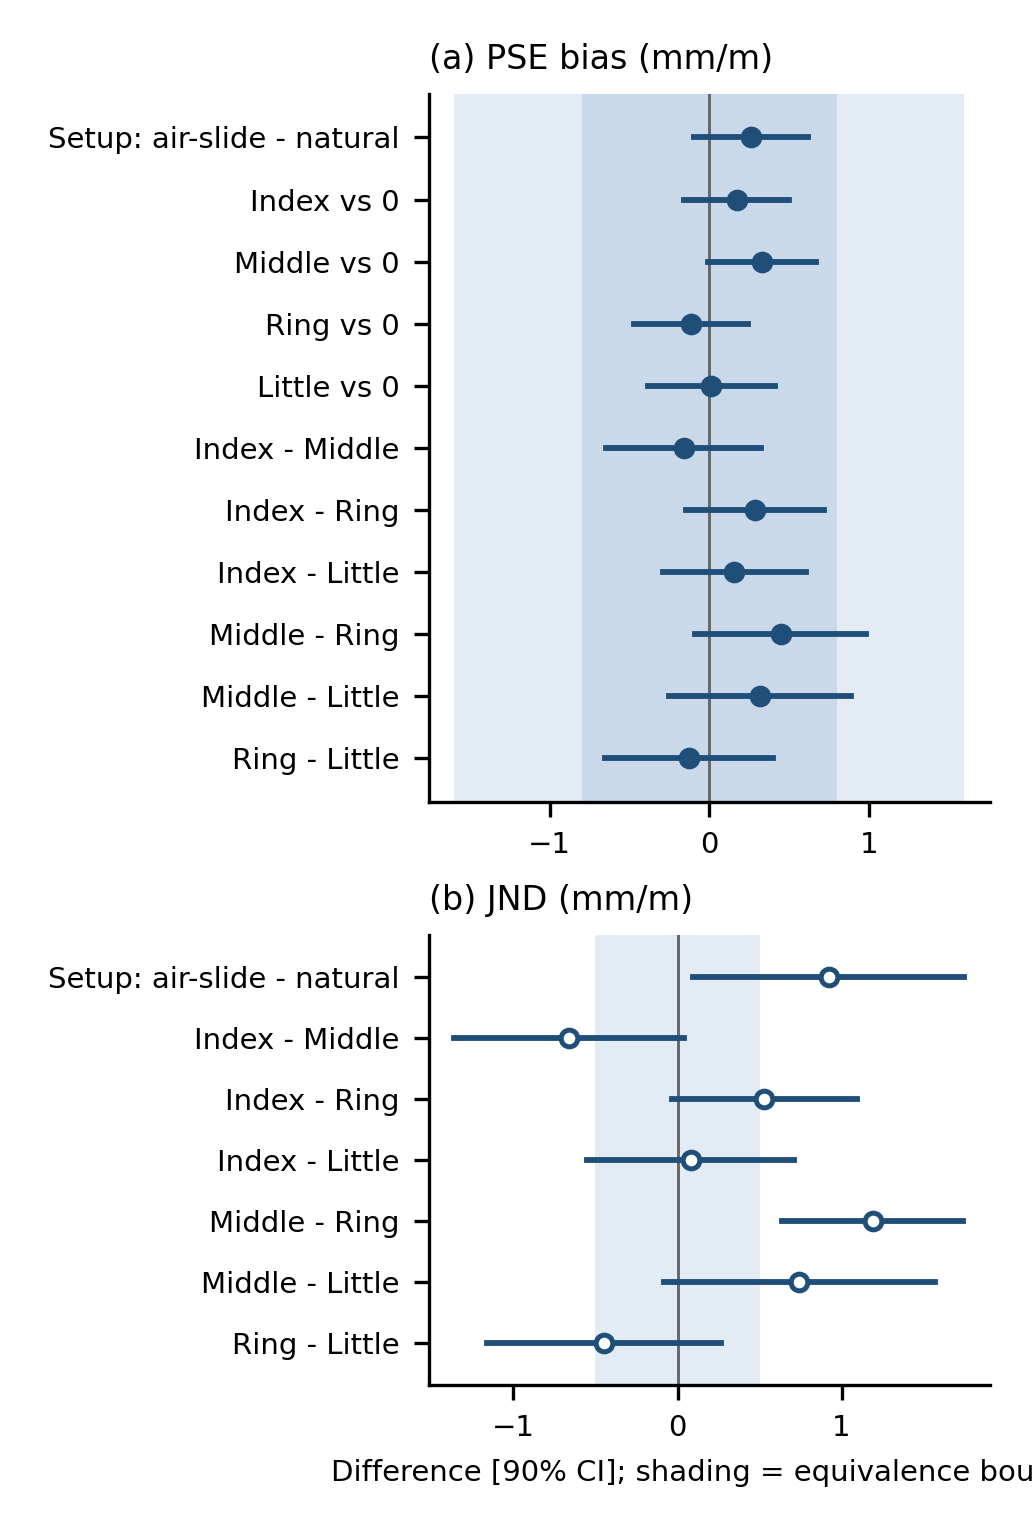

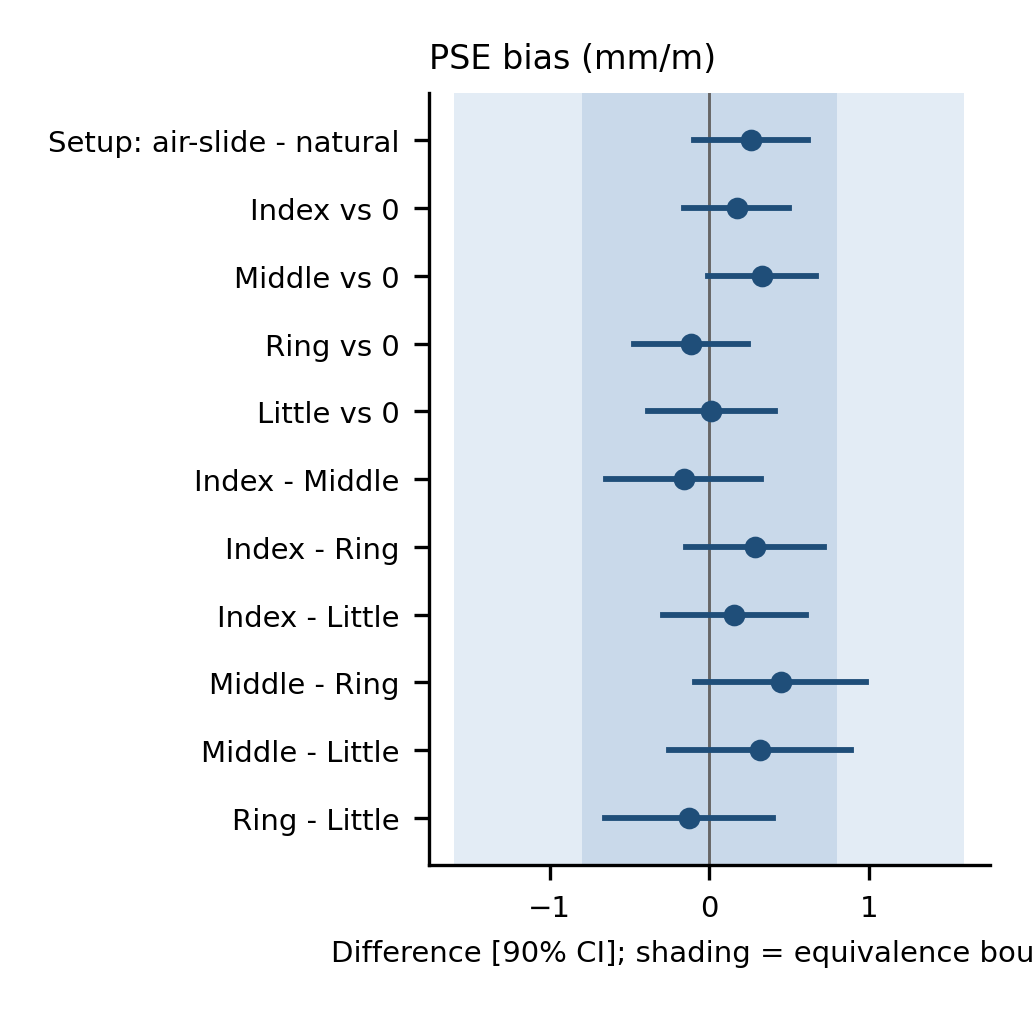

paper figure files: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\analysis\tost_equivalence\results\L_N_E_N39\figures\equivalence_paper.png C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\analysis\tost_equivalence\results\L_N_E_N39\figures\equivalence_paper_bias.png (+ .pdf)


In [11]:
fig2 = T.paper_figure(setup, pairs, zero, os.path.join(P["figures"], "equivalence_paper.png"), panels=PAPER_PANELS)
fig1 = T.paper_figure(setup, pairs, zero, os.path.join(P["figures"], "equivalence_paper_bias.png"), panels=("bias",))
display(Image(fig2, width=420)); display(Image(fig1, width=420))
print("paper figure files:", fig2, fig1, "(+ .pdf)")


## 11. Report sentences

Every number the paper's ANOVA sentence and equivalence paragraph need, generated from the tables above
and saved to `report_sentences.md`. Adjust wording, not numbers.

In [12]:
report = T.report_sentences(df, setup, pairs, verdict, zero, an, bf_ttest, bf_pairs, mde, JND_REF)
with open(os.path.join(P["root"], "report_sentences.md"), "w", encoding="utf-8") as fh:
    fh.write(report)
display(Markdown(report))
print("Outputs:", sorted(os.listdir(P["csv"])), sorted(os.listdir(P["figures"])))


## Numbers for the paper (N = 39: 20 air-slide, 19 natural)

### ANOVA sentence (Results, after the ANOVA table)

PSE bias showed no significant effect of Setup, Finger, or their interaction (all p >= 0.232). For JND, the Setup effect was not significant (F(1,37) = 3.49, p = 0.070, np2 = 0.086); the Finger effect was significant (F(2.47,91.5) = 3.00, p_GG = 0.042, np2 = 0.075); Holm post hoc middle vs ring: t(38) = 3.63, p = 0.005, d = 0.55.

### Equivalence paragraph

Bounds: +/-1 JND = +/-1.6 mm/m (median per-participant JND 1.61), +/-0.5 JND = +/-0.8; JND +/-0.5 mm/m. Welch t with Welch-Satterthwaite df.

Setup difference in bias = 0.26 mm/m, 90% CI [-0.10, 0.62], t(34.9) = -6.32, p_TOST < .001 at +/-1 JND; p_TOST = 0.008 at +/-0.5 JND. Each finger vs 0 at +/-0.5 JND: all p_TOST <= 0.013 (all equivalent). Six finger pairs at +/-1 JND: all equivalent (Holm-corrected p_TOST max < .001).

JND setup difference = 0.92 mm/m, 90% CI [0.10, 1.75], p_TOST = 0.803; Welch t(33.0) = 1.89, p = 0.068; BF01 = 0.81. Middle - ring JND = 1.19 [0.64, 1.74], BF10 = 36; index - little BF01 = 5.7. Pairs that differed (90% CI excludes 0): Middle-Ring.

MDE at 80% power: 0.62 mm/m (bias), 1.42 mm/m (JND).

Bias BF01 (setup, r = 0.707) = 1.78; finger pairs BF01 2.3-5.4 (optional).


Outputs: ['anova.csv', 'bf_pairs.csv', 'bf_ttest.csv', 'for_jasp_wide.csv', 'mde.csv', 'pairs.csv', 'posthoc.csv', 'robust.csv', 'sensitivity.csv', 'setup.csv', 'step0.csv', 'step2.csv', 'verdict.csv', 'zero.csv'] ['equivalence_paper.pdf', 'equivalence_paper.png', 'equivalence_paper_bias.pdf', 'equivalence_paper_bias.png']


## References

* Lakens, D. (2017). Equivalence tests: A practical primer for t tests, correlations, and meta-analyses. *SPPS, 8*(4), 355-362. doi:10.1177/1948550617697177
* Delacre, M., Lakens, D., & Leys, C. (2017). Why psychologists should by default use Welch's t-test instead of Student's t-test. *IRSP, 30*(1), 92-101. doi:10.5334/irsp.82
* Welch, B. L. (1947). The generalization of 'Student's' problem when several different population variances are involved. *Biometrika, 34*, 28-35.
* Rouder, J. N., et al. (2009). Bayesian t tests for accepting and rejecting the null hypothesis. *Psychon. Bull. Rev., 16*, 225-237.
